In [1]:
from typing import Any

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# MNIST 이미지 데이터셋 가져오기

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.34MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]


In [33]:
len(train_dataset)

60000

In [3]:
images, label = next(iter(train_loader))

images.shape, label.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [5]:
# FC 레이어에 넣기 위해서 batch를 제외한 이미지의 C, H, W 를 하나의 차원으로 병합
x = images.view(images.size(0), -1)

x.shape

torch.Size([64, 784])

# Encoder 만들어서 hidden latent space 만들어서 분포의 평균과 분산 만들기

In [6]:
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.fc = nn.Linear(784, 256)

        # 평균으로 만드는 레이어 (대략적인 위치)
        self.fc_mu = nn.Linear(256, latent_dim)
        # 표준편차로 만드는 레이어 (불확실성)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def encode(self, x):
        # b, 784
        h = torch.relu(self.fc(x))

        # b, 2
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

In [7]:
model = VAE(latent_dim=2)

mu, logvar = model.encode(x)

mu.shape, logvar.shape

(torch.Size([64, 2]), torch.Size([64, 2]))

In [19]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 256)
        self.fc3 = nn.Linear(256, 784)


    def encode(self, x):
        h = torch.relu(self.fc1(x))

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        x_hat = torch.sigmoid(self.fc3(h))

        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        x_hat = self.decode(z)

        return x_hat, mu, logvar

In [8]:
def reparameterize(self, mu, logvar):
    # e^x 를 해주는 메서드
    std = torch.exp(0.5 * logvar)
    # 동일한 shape의 0~1 데이터 만들어주기
    eps = torch.randn_like(std)

    z = mu + eps * std
    return z

In [23]:
def loss_function(x_hat, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(
        x_hat, x, reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

In [20]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = VAE(latent_dim=2).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3
)

In [24]:
for epoch in range(10):
    model.train()

    total_loss = 0

    for images, _ in train_loader:
        x = images.view(images.size(0), -1).to(DEVICE)

        optimizer.zero_grad()

        x_hat, mu, logvar = model(x)

        loss = loss_function(
            x_hat, x, mu, logvar
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"""
epoch: {epoch+1} | Loss: {total_loss / len(train_dataset):.4f}
""")


epoch: 1 | Loss: 183.9590


epoch: 2 | Loss: 165.9789


epoch: 3 | Loss: 162.3396


epoch: 4 | Loss: 160.1577


epoch: 5 | Loss: 158.5932


epoch: 6 | Loss: 157.3574


epoch: 7 | Loss: 156.3859


epoch: 8 | Loss: 155.5627


epoch: 9 | Loss: 154.9528


epoch: 10 | Loss: 154.4376



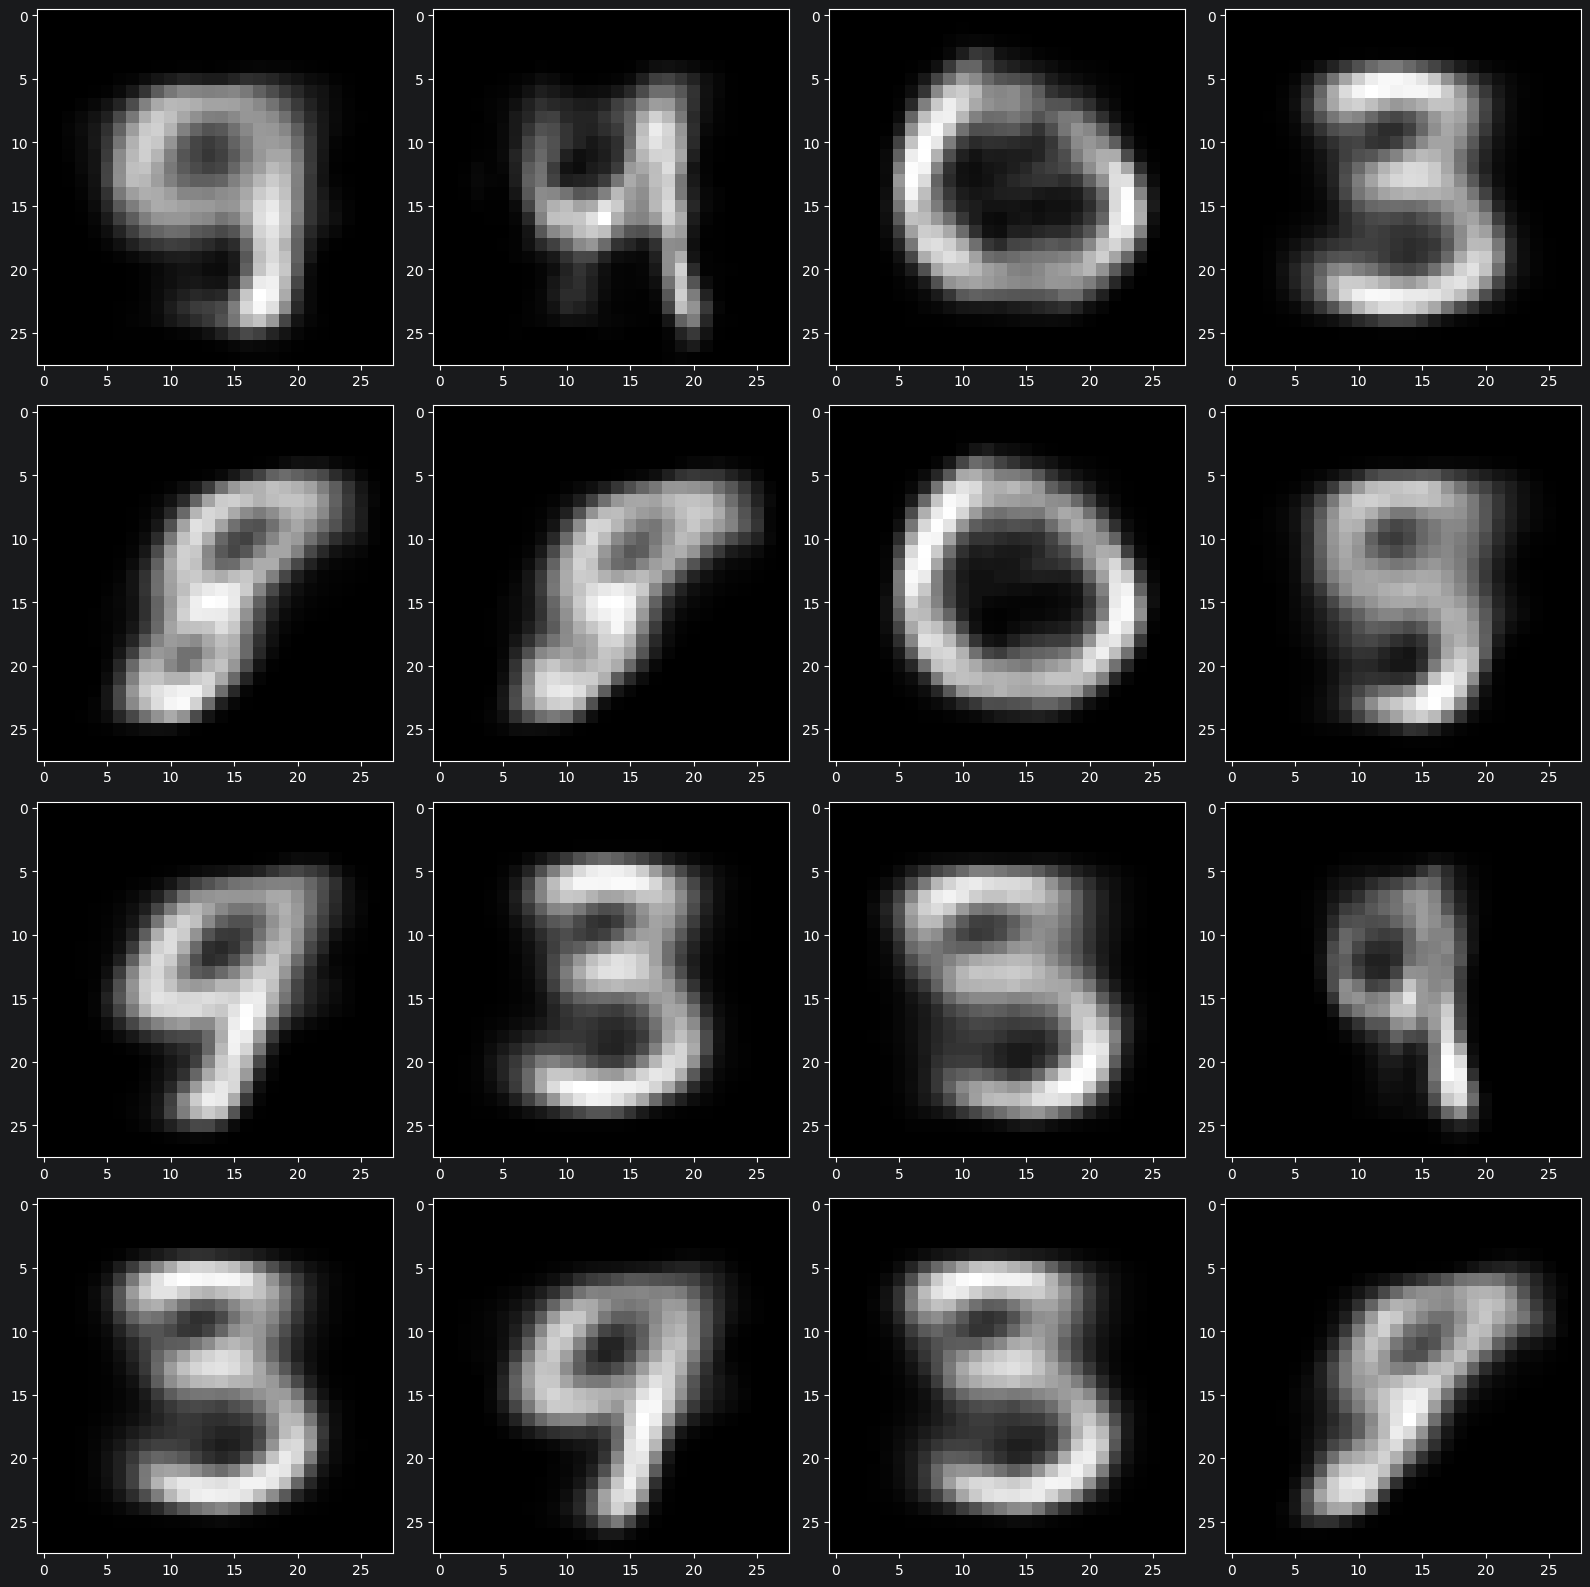

In [32]:
z = torch.randn(16, 2).to(DEVICE)

with torch.no_grad():
    generated = model.decode(z)

generated = generated.view(-1, 1, 28, 28)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for idx, ax in enumerate(axes.flatten()):
    ax.imshow(generated[idx].cpu().squeeze(0), cmap="gray")

plt.tight_layout()
plt.show()